First 5 rows:
    satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  

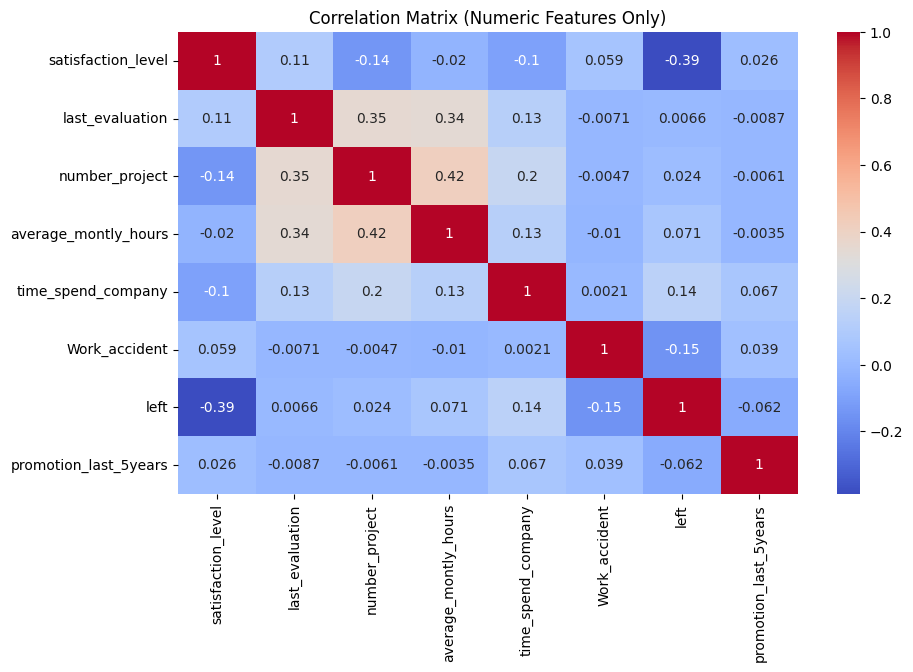


Mean values grouped by retention:

      satisfaction_level  last_evaluation  number_project  \
left                                                        
0               0.666810         0.715473        3.786664   
1               0.440098         0.718113        3.855503   

      average_montly_hours  time_spend_company  Work_accident  left  \
left                                                                  
0               199.060203            3.380032       0.175009   0.0   
1               207.419210            3.876505       0.047326   1.0   

      promotion_last_5years  
left                         
0                  0.026251  
1                  0.005321  


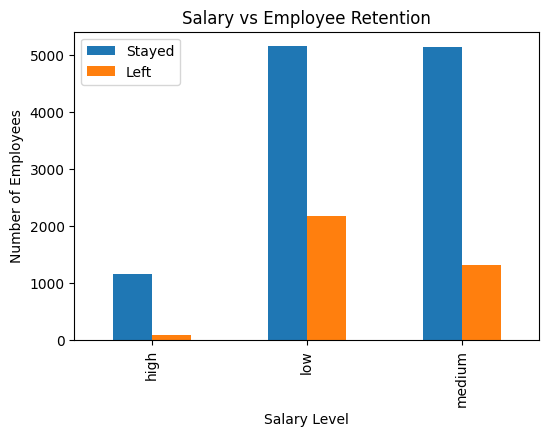

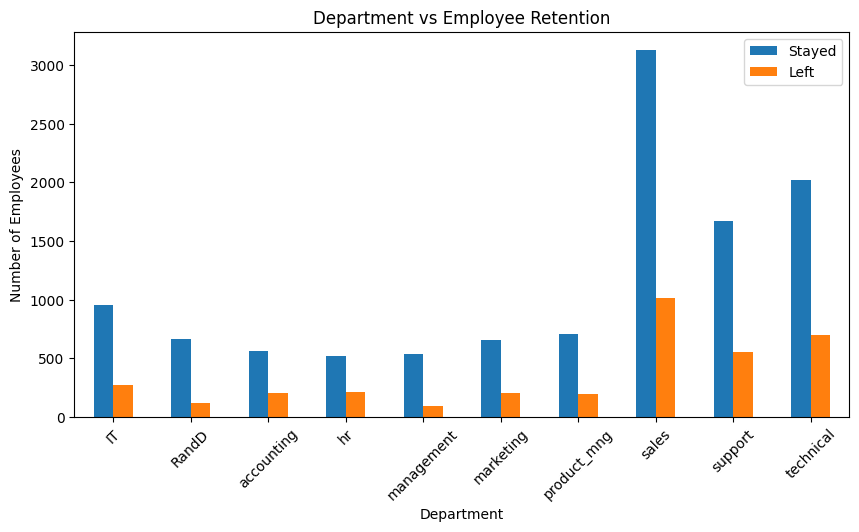


Model Accuracy: 0.765

Confusion Matrix:
 [[2132  162]
 [ 543  163]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.93      0.86      2294
           1       0.50      0.23      0.32       706

    accuracy                           0.77      3000
   macro avg       0.65      0.58      0.59      3000
weighted avg       0.73      0.77      0.73      3000



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("HR_comma_sep.csv")

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

#Exploratory Data Analysis (EDA)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()


print("\nMean values grouped by retention:\n")
print(df.groupby('left')[numeric_df.columns].mean())

#Salary vs Retention (Bar Chart)
salary_retention = pd.crosstab(df['salary'], df['left'])
salary_retention.plot(kind='bar', figsize=(6,4))
plt.title("Salary vs Employee Retention")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.legend(["Stayed", "Left"])
plt.show()

#Department vs Retention (Bar Chart)
dept_retention = pd.crosstab(df['Department'], df['left'])
dept_retention.plot(kind='bar', figsize=(10,5))
plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.legend(["Stayed", "Left"])
plt.show()


X = df[['satisfaction_level',
        'average_montly_hours',
        'promotion_last_5years',
        'salary',
        'Department']]

y = df['left']

X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#Predictions and Accuracy
y_pred = model.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("HR_comma_sep.csv")

#Feature Selection (Based on EDA)

X = df[['satisfaction_level',
        'average_montly_hours',
        'promotion_last_5years',
        'salary']]

y = df['left'].values

salary_map = {'low':0, 'medium':1, 'high':2}
X['salary'] = X['salary'].map(salary_map)


X = X.values

X = (X - X.mean(axis=0)) / X.std(axis=0)


m = X.shape[0]
X = np.hstack((np.ones((m,1)), X))

#Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    cost = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
    return cost


def gradient_descent(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    theta = np.zeros(n)

    for i in range(epochs):
        z = np.dot(X, theta)
        h = sigmoid(z)
        gradient = np.dot(X.T, (h - y)) / m
        theta -= lr * gradient

        if i % 200 == 0:
            print("Cost at iteration", i, ":", compute_cost(X, y, theta))

    return theta


theta = gradient_descent(X, y)

#Prediction
def predict(X, theta):
    probs = sigmoid(np.dot(X, theta))
    return np.array([1 if p >= 0.5 else 0 for p in probs])

y_pred = predict(X, theta)

#Accuracy
accuracy = np.mean(y_pred == y) * 100
print("\nModel Accuracy (Manual Logistic Regression):", accuracy, "%")

/tmp/ipython-input-2114719783.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['salary'] = X['salary'].map(salary_map)


Cost at iteration 0 : 0.6921274893912137
Cost at iteration 200 : 0.5634778112733763
Cost at iteration 400 : 0.5121748947120531
Cost at iteration 600 : 0.4886477604458792
Cost at iteration 800 : 0.4766150668392215

Model Accuracy (Manual Logistic Regression): 78.32522168144543 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

=== Sklearn Logistic Regression ===
Accuracy: 0.9523809523809523

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



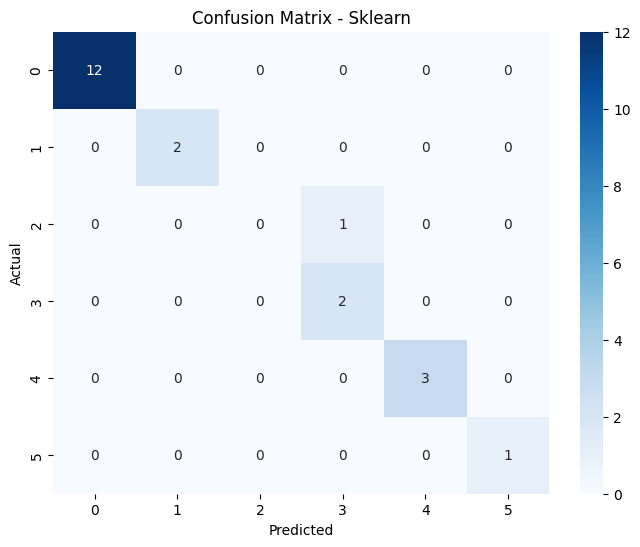


=== Manual Logistic Regression ===
Accuracy: 1.0

Confusion Matrix (Manual):
 [[41  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0]
 [ 0  0  5  0  0  0  0]
 [ 0  0  0 13  0  0  0]
 [ 0  0  0  0  4  0  0]
 [ 0  0  0  0  0  8  0]
 [ 0  0  0  0  0  0 10]]


In [8]:
# Multiclass Logistic Regression - Zoo Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("zoo-data.csv")

X = df.drop(columns=['class_type', 'animal_name'])
y = df['class_type']

if y.dtype == 'object':
    y = y.astype('category').cat.codes

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

print("=== Sklearn Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sklearn))

cm = confusion_matrix(y_test, y_pred_sklearn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Sklearn")
plt.show()


X_manual = X.values
y_manual = y.values

classes = np.unique(y_manual)
class_dict = {c:i for i,c in enumerate(classes)}
y_manual = np.array([class_dict[label] for label in y_manual])
K = len(classes)
m, n = X_manual.shape

X_manual = (X_manual - X_manual.mean(axis=0)) / X_manual.std(axis=0)

X_manual = np.hstack((np.ones((m,1)), X_manual))
n += 1

Y_onehot = np.zeros((m,K))
Y_onehot[np.arange(m), y_manual] = 1

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / exp_z.sum(axis=1, keepdims=True)

theta = np.zeros((n, K))
lr = 0.1
epochs = 2000

for _ in range(epochs):
    Z = X_manual @ theta
    H = softmax(Z)
    gradient = (X_manual.T @ (H - Y_onehot)) / m
    theta -= lr * gradient

y_pred_manual = np.argmax(softmax(X_manual @ theta), axis=1)
accuracy_manual = np.mean(y_pred_manual == y_manual)
print("\n=== Manual Logistic Regression ===")
print("Accuracy:", accuracy_manual)

cm_manual = np.zeros((K,K), dtype=int)
for true, pred in zip(y_manual, y_pred_manual):
    cm_manual[true, pred] += 1
print("\nConfusion Matrix (Manual):\n", cm_manual)